# Laboratorio 8: Máquinas Vectoriales de Soporte (SVM)
## SmartStay Advisors - Clasificación y Regresión de Precios en Airbnb

**Curso:** CC3074 - Minería de Datos  
**Universidad del Valle de Guatemala**  
**Semestre I - 2026**

- Martin Pez
- Karen

## 1. Configuración Inicial

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')

# CONFIGURACIÓN EMBEBIDA
SEED = 42
TRAIN_SIZE = 0.70
N_SAMPLES = 15000
PRICE_MIN = 0
PRICE_MAX = 1000

np.random.seed(SEED)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(f"✅ Configuración lista")
print(f"   Seed: {SEED}")
print(f"   Train/Test: {TRAIN_SIZE}/{1-TRAIN_SIZE}")
print(f"   Muestras: {N_SAMPLES}")
print(f"   Rango de precios: ${PRICE_MIN} - ${PRICE_MAX}")

✅ Configuración lista
   Seed: 42
   Train/Test: 0.7/0.30000000000000004
   Muestras: 15000
   Rango de precios: $0 - $1000


## 2. Importar Librerías de ML

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score,
    mean_squared_error, r2_score, mean_absolute_error
)

print("✅ Librerías importadas")

✅ Librerías importadas


## 3. Cargar y Preparar Datos

In [3]:
import rdata as rdata_pkg

print("📖 Cargando datos desde listings.RData...")
parsed = rdata_pkg.read_rda('listings.RData')
listings = parsed['listings']
print(f"✅ Datos cargados: {listings.shape}")
print(f"Columnas (primeras 10): {listings.columns.tolist()[:10]}")

📖 Cargando datos desde listings.RData...
✅ Datos cargados: (171748, 80)
Columnas (primeras 10): ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id']


## 4. Limpieza de Datos y Exploración (Actividades 2 y 4)

In [4]:
print("🧹 Limpiando datos...")

listings['price_num'] = pd.to_numeric(
    listings['price'].str.replace('$', '').str.replace(',', ''),
    errors='coerce'
)

listings['superhost']       = (listings['host_is_superhost'] == 't').astype(int)
listings['instant_book']    = (listings['instant_bookable']  == 't').astype(int)
listings['es_entire_home']  = (listings['room_type'] == 'Entire home/apt').astype(int)
listings['es_private_room'] = (listings['room_type'] == 'Private room').astype(int)

features = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'availability_365', 'number_of_reviews',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value',
    'latitude', 'longitude', 'calculated_host_listings_count',
    'reviews_per_month', 'superhost', 'instant_book',
    'es_entire_home', 'es_private_room'
]

datos = listings[['price_num'] + features].copy()
datos = datos.dropna(subset=['price_num', 'review_scores_rating',
                             'bathrooms', 'bedrooms', 'beds', 'reviews_per_month'])
datos = datos[(datos['price_num'] > PRICE_MIN) & (datos['price_num'] <= PRICE_MAX)]

print(f"✅ Datos limpios: {datos.shape}")
print(f"\nPrecio - Estadísticas:")
print(datos['price_num'].describe())

🧹 Limpiando datos...
✅ Datos limpios: (60619, 22)

Precio - Estadísticas:
count       60619.0
mean     229.135568
std      170.627508
min             8.0
25%           115.0
50%           178.0
75%           285.0
max          1000.0
Name: price_num, dtype: Float64


## 5. Categorización de Precios (P33/P66)

In [5]:
q33 = datos['price_num'].quantile(0.33)
q66 = datos['price_num'].quantile(0.66)

print(f"P33 (barata/media): ${q33:.2f}")
print(f"P66 (media/cara):   ${q66:.2f}")

datos['precio_cat'] = pd.cut(
    datos['price_num'],
    bins=[-np.inf, q33, q66, np.inf],
    labels=['barata', 'media', 'cara'],
    right=True
)

print(f"\nDistribución:")
print(datos['precio_cat'].value_counts(sort=False))
print(f"\nPorcentajes:")
print(datos['precio_cat'].value_counts(normalize=True, sort=False) * 100)

P33 (barata/media): $133.00
P66 (media/cara):   $237.00

Distribución:
precio_cat
barata    20035
media     20096
cara      20488
Name: count, dtype: int64

Porcentajes:
precio_cat
barata    33.050694
media     33.151322
cara      33.797984
Name: proportion, dtype: float64


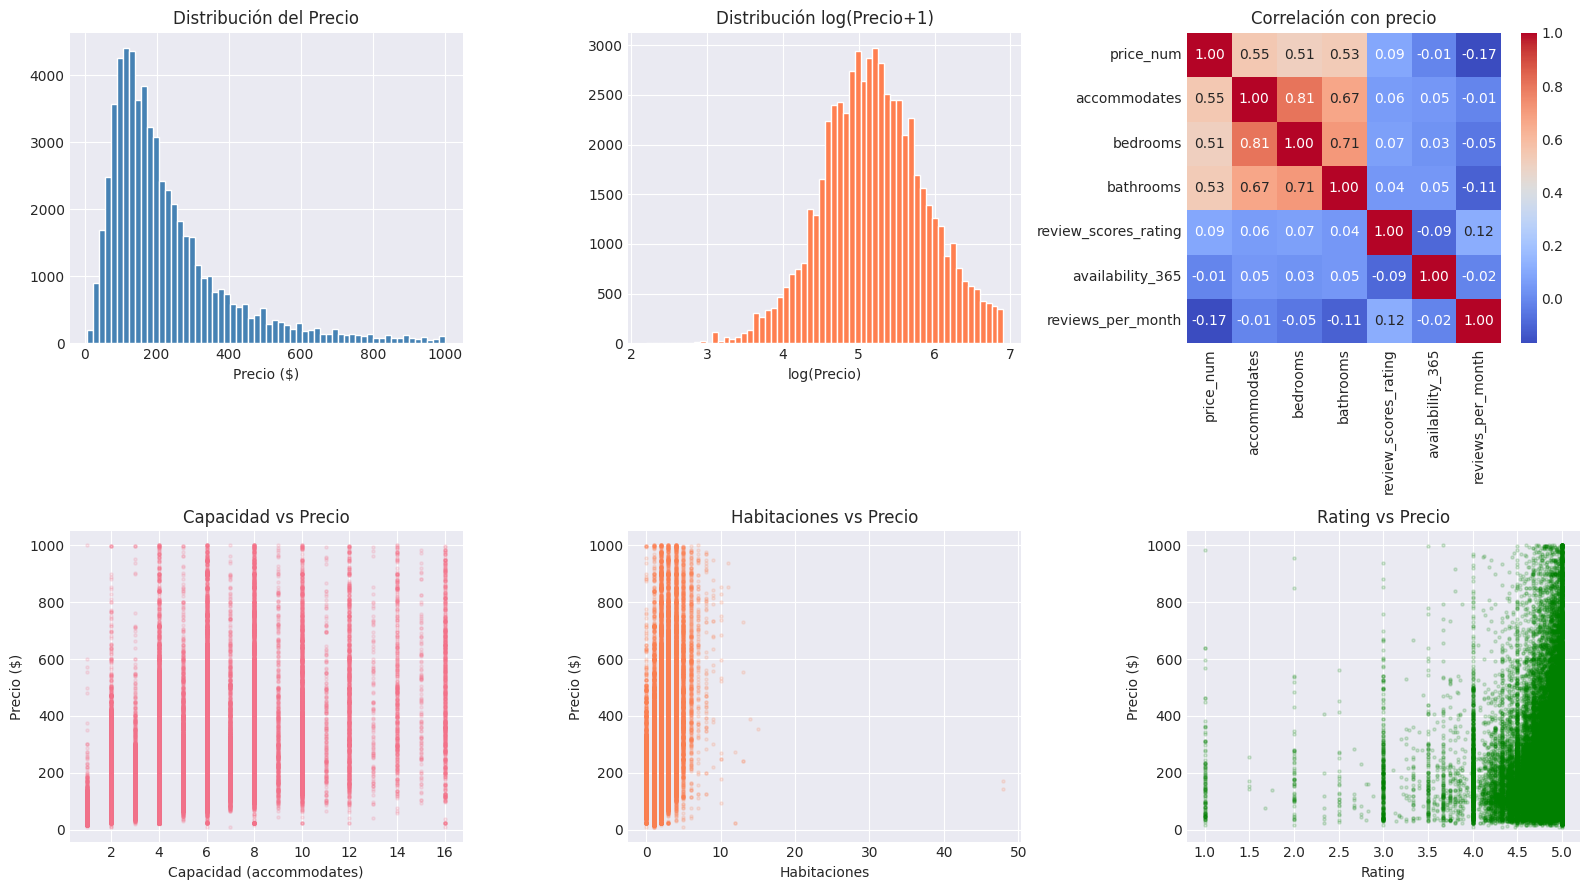

⚠️  Por qué SVM requiere estas transformaciones:
  1. ESCALADO obligatorio: SVM maximiza márgenes via distancias euclidianas.
     Sin escalar, 'price_num' (8–1000) domina sobre 'bathrooms' (0–10).
     → StandardScaler: cada feature queda con μ=0, σ=1.
  2. Sin NaN: SVM no maneja valores faltantes.
     → dropna() sobre review_scores, bathrooms, bedrooms, beds.
  3. Variables categóricas → binarias: room_type y host flags.
  4. Variable respuesta: precio continuo categorizado por P33/P66
     para obtener 3 clases balanceadas (~33% cada una).


In [6]:
# EDA: distribución, correlaciones y justificación de transformaciones para SVM
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0,0].hist(datos['price_num'].astype(float), bins=60, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribución del Precio')
axes[0,0].set_xlabel('Precio ($)')

axes[0,1].hist(np.log1p(datos['price_num'].astype(float)), bins=60, color='coral', edgecolor='white')
axes[0,1].set_title('Distribución log(Precio+1)')
axes[0,1].set_xlabel('log(Precio)')

corr_cols = ['price_num','accommodates','bedrooms','bathrooms',
             'review_scores_rating','availability_365','reviews_per_month']
corr_data = datos[corr_cols].astype(float).corr()
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0,2])
axes[0,2].set_title('Correlación con precio')

axes[1,0].scatter(datos['accommodates'].astype(float),
                  datos['price_num'].astype(float), alpha=0.15, s=5)
axes[1,0].set_xlabel('Capacidad (accommodates)')
axes[1,0].set_ylabel('Precio ($)')
axes[1,0].set_title('Capacidad vs Precio')

axes[1,1].scatter(datos['bedrooms'].astype(float),
                  datos['price_num'].astype(float), alpha=0.15, s=5, color='coral')
axes[1,1].set_xlabel('Habitaciones')
axes[1,1].set_ylabel('Precio ($)')
axes[1,1].set_title('Habitaciones vs Precio')

axes[1,2].scatter(datos['review_scores_rating'].astype(float),
                  datos['price_num'].astype(float), alpha=0.15, s=5, color='green')
axes[1,2].set_xlabel('Rating')
axes[1,2].set_ylabel('Precio ($)')
axes[1,2].set_title('Rating vs Precio')

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()

print("⚠️  Por qué SVM requiere estas transformaciones:")
print("  1. ESCALADO obligatorio: SVM maximiza márgenes via distancias euclidianas.")
print("     Sin escalar, 'price_num' (8–1000) domina sobre 'bathrooms' (0–10).")
print("     → StandardScaler: cada feature queda con μ=0, σ=1.")
print("  2. Sin NaN: SVM no maneja valores faltantes.")
print("     → dropna() sobre review_scores, bathrooms, bedrooms, beds.")
print("  3. Variables categóricas → binarias: room_type y host flags.")
print("  4. Variable respuesta: precio continuo categorizado por P33/P66")
print("     para obtener 3 clases balanceadas (~33% cada una).")

## 6. División Train/Test Estratificada

In [7]:
np.random.seed(SEED)
idx_muestra = datos.groupby('precio_cat', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), int(N_SAMPLES / 3)), random_state=SEED)
).index.tolist()

datos_sample = datos.loc[idx_muestra].copy()
if len(datos_sample) > N_SAMPLES:
    datos_sample = datos_sample.iloc[:N_SAMPLES]

print(f"Muestra: {len(datos_sample)} filas")

np.random.seed(SEED)
n = len(datos_sample)
idx_tr = np.random.choice(n, size=int(0.70 * n), replace=False)
idx_te = np.array([i for i in range(n) if i not in idx_tr])

train = datos_sample.iloc[idx_tr].reset_index(drop=True)
test = datos_sample.iloc[idx_te].reset_index(drop=True)

print(f"\n✅ Train: {len(train)} | Test: {len(test)}")
print(f"\nDistribución en TRAIN:")
print(train['precio_cat'].value_counts(sort=False))
print(f"\nDistribución en TEST:")
print(test['precio_cat'].value_counts(sort=False))

Muestra: 15000 filas

✅ Train: 10500 | Test: 4500

Distribución en TRAIN:
precio_cat
barata    3562
media     3516
cara      3422
Name: count, dtype: int64

Distribución en TEST:
precio_cat
barata    1438
media     1484
cara      1578
Name: count, dtype: int64


## 7. Preparación para Clasificación

In [8]:
scaler = StandardScaler()

X_train = train[features].copy()
X_test = test[features].copy()
y_train = train['precio_cat'].copy()
y_test = test['precio_cat'].copy()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_clf = pd.DataFrame(X_train_scaled, columns=features)
X_test_clf = pd.DataFrame(X_test_scaled, columns=features)

print(f"✅ Datos escalados para clasificación")
print(f"   X_train: {X_train_clf.shape}")
print(f"   X_test:  {X_test_clf.shape}")

✅ Datos escalados para clasificación
   X_train: (10500, 21)
   X_test:  (4500, 21)


## 8. Preparación para Regresión

In [9]:
scaler_reg = StandardScaler()

y_train_reg = train['price_num'].copy()
y_test_reg = test['price_num'].copy()

X_train_reg_scaled = scaler_reg.fit_transform(X_train)
X_test_reg_scaled = scaler_reg.transform(X_test)

X_train_reg = pd.DataFrame(X_train_reg_scaled, columns=features)
X_test_reg = pd.DataFrame(X_test_reg_scaled, columns=features)

print(f"✅ Datos escalados para regresión")
print(f"   X_train: {X_train_reg.shape}")
print(f"   y_train: min=${y_train_reg.min():.2f}, max=${y_train_reg.max():.2f}")

✅ Datos escalados para regresión
   X_train: (10500, 21)
   y_train: min=$8.00, max=$1000.00


## 9. SVM - CLASIFICACIÓN (Actividad 4)
### Múltiples kernels y parámetros

In [ ]:
import time

svm_classifiers = {}
kernels    = ['linear', 'rbf', 'poly']
C_values   = [0.1, 1, 10]
gamma_values = ['scale', 0.001, 0.01]

print("🤖 Entrenando SVM Clasificadores...\n")

for kernel in kernels:
    print(f"Kernel: {kernel}")
    for c_val in C_values:
        for gamma_val in gamma_values:
            model_name = f'SVM_{kernel}_C{c_val}_G{str(gamma_val).replace(".", "_")}'

            svm = SVC(kernel=kernel, C=c_val, gamma=gamma_val,
                      random_state=SEED, probability=True)

            t0 = time.time()
            svm.fit(X_train_clf, y_train)
            t_train = time.time() - t0

            train_acc = svm.score(X_train_clf, y_train)
            test_acc  = svm.score(X_test_clf,  y_test)

            svm_classifiers[model_name] = {
                'model':     svm,
                'kernel':    kernel,
                'C':         c_val,
                'gamma':     gamma_val,
                'train_acc': train_acc,
                'test_acc':  test_acc,
                'overfit':   train_acc - test_acc,
                'tiempo_s':  round(t_train, 2)
            }

            print(f"  {model_name}: train={train_acc:.4f}, test={test_acc:.4f}, "
                  f"overfit={train_acc-test_acc:.4f}, tiempo={t_train:.1f}s")

print(f"\n✅ {len(svm_classifiers)} modelos SVM entrenados")

🤖 Entrenando SVM Clasificadores...

Kernel: linear
  SVM_linear_C0.1_Gscale: train=0.6307, test=0.6316, overfit=-0.0009, tiempo=13.5s
  SVM_linear_C0.1_G0_001: train=0.6307, test=0.6316, overfit=-0.0009, tiempo=12.9s
  SVM_linear_C0.1_G0_01: train=0.6307, test=0.6316, overfit=-0.0009, tiempo=12.4s
  SVM_linear_C1_Gscale: train=0.6322, test=0.6338, overfit=-0.0016, tiempo=20.9s
  SVM_linear_C1_G0_001: train=0.6322, test=0.6338, overfit=-0.0016, tiempo=21.0s
  SVM_linear_C1_G0_01: train=0.6322, test=0.6338, overfit=-0.0016, tiempo=21.5s
  SVM_linear_C10_Gscale: train=0.6326, test=0.6336, overfit=-0.0010, tiempo=70.5s


## 10. Modelos Baseline - CLASIFICACIÓN (Actividad 9)
### Comparación con entregas anteriores

In [ ]:
baseline_classifiers = {
    'DecisionTree':      DecisionTreeClassifier(random_state=SEED),
    'RandomForest':      RandomForestClassifier(n_estimators=100, random_state=SEED),
    'GaussianNB':        GaussianNB(),
    'KNN_5':             KNeighborsClassifier(n_neighbors=5),
    'KNN_10':            KNeighborsClassifier(n_neighbors=10),
    'LogisticRegression':LogisticRegression(max_iter=1000, random_state=SEED)
}

baseline_results_clf = {}
print("🔬 Entrenando modelos baseline...\n")

for name, model in baseline_classifiers.items():
    print(f"  {name}...", end=' ')
    t0 = time.time()
    model.fit(X_train_clf, y_train)
    t_train = time.time() - t0

    train_acc = model.score(X_train_clf, y_train)
    test_acc  = model.score(X_test_clf,  y_test)

    baseline_results_clf[name] = {
        'model':     model,
        'train_acc': train_acc,
        'test_acc':  test_acc,
        'overfit':   train_acc - test_acc,
        'tiempo_s':  round(t_train, 2)
    }
    print(f"train={train_acc:.4f}, test={test_acc:.4f}, "
          f"overfit={train_acc-test_acc:.4f}, tiempo={t_train:.1f}s")

print(f"\n✅ Modelos baseline entrenados")

## 11. Matriz de Confusión (Actividad 6)
### SVM vs Mejor Baseline

In [ ]:
best_svm_clf = max(svm_classifiers.items(), key=lambda x: x[1]['test_acc'])
best_baseline_clf = max(baseline_results_clf.items(), key=lambda x: x[1]['test_acc'])

print(f"Mejor SVM: {best_svm_clf[0]}")
print(f"  Test Accuracy: {best_svm_clf[1]['test_acc']:.4f}")
print(f"\nMejor Baseline: {best_baseline_clf[0]}")
print(f"  Test Accuracy: {best_baseline_clf[1]['test_acc']:.4f}")

y_pred_svm = best_svm_clf[1]['model'].predict(X_test_clf)
y_pred_baseline = best_baseline_clf[1]['model'].predict(X_test_clf)

cm_svm = confusion_matrix(y_test, y_pred_svm, labels=['barata', 'media', 'cara'])
cm_baseline = confusion_matrix(y_test, y_pred_baseline, labels=['barata', 'media', 'cara'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['barata', 'media', 'cara'],
            yticklabels=['barata', 'media', 'cara'])
axes[0].set_title(f'Matriz de Confusión - {best_svm_clf[0]}')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicción')

sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['barata', 'media', 'cara'],
            yticklabels=['barata', 'media', 'cara'])
axes[1].set_title(f'Matriz de Confusión - {best_baseline_clf[0]}')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicción')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Matrices de confusión guardadas")

## 12. Análisis de Overfitting (Actividad 7, 10)
### Comparación de modelos

In [ ]:
comparison_data = []

for name, data in svm_classifiers.items():
    comparison_data.append({
        'Modelo': name, 'Tipo': 'SVM',
        'Train Acc': round(data['train_acc'], 4),
        'Test Acc':  round(data['test_acc'],  4),
        'Overfit':   round(data['overfit'],   4),
        'Tiempo(s)': data['tiempo_s']
    })
for name, data in baseline_results_clf.items():
    comparison_data.append({
        'Modelo': name, 'Tipo': 'Baseline',
        'Train Acc': round(data['train_acc'], 4),
        'Test Acc':  round(data['test_acc'],  4),
        'Overfit':   round(data['overfit'],   4),
        'Tiempo(s)': data['tiempo_s']
    })

df_comparison = pd.DataFrame(comparison_data).sort_values('Test Acc', ascending=False)
print("📊 Tabla Comparativa - CLASIFICACIÓN (con tiempo y overfit)\n")
print(df_comparison.to_string(index=False))

# ¿Qué parámetros determinan sobreajuste en clasificación?
print("\n🔍 PARÁMETROS PARA DETECTAR SOBREAJUSTE EN CLASIFICACIÓN:")
print("  • Train Acc >> Test Acc  → sobreajuste (brecha > 0.10 es señal clara)")
print("  • Cross-val score bajo en train → subajuste")
print("  • Accuracy NO es suficiente: usar también F1 por clase, precisión y recall")
print("  • Árbol de decisión sin podar tiende a sobreajustar (Train≈1.0, Test≪1.0)")
print("  • SVM con C muy alto memoriza el train (margen duro) → más overfit")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_top = df_comparison.head(15)
colors = ['#2196F3' if t == 'SVM' else '#4CAF50' for t in df_top['Tipo']]
axes[0].barh(range(len(df_top)), df_top['Test Acc'], color=colors)
axes[0].set_yticks(range(len(df_top)))
axes[0].set_yticklabels(df_top['Modelo'], fontsize=8)
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Test Accuracy — Top 15')
axes[0].grid(axis='x', alpha=0.3)

axes[1].scatter(df_comparison[df_comparison['Tipo']=='SVM']['Test Acc'],
                df_comparison[df_comparison['Tipo']=='SVM']['Overfit'],
                label='SVM', s=80, alpha=0.7, color='#2196F3')
axes[1].scatter(df_comparison[df_comparison['Tipo']=='Baseline']['Test Acc'],
                df_comparison[df_comparison['Tipo']=='Baseline']['Overfit'],
                label='Baseline', s=80, alpha=0.7, color='#4CAF50', marker='D')
axes[1].axhline(0.10, color='orange', linestyle='--', alpha=0.7, label='Umbral overfit (0.10)')
axes[1].axhline(0,    color='red',    linestyle='--', alpha=0.4)
axes[1].set_xlabel('Test Accuracy')
axes[1].set_ylabel('Overfitting (Train − Test)')
axes[1].set_title('Diagnóstico de Overfitting')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_classification.png', dpi=150, bbox_inches='tight')
plt.show()

# Análisis de equivocaciones (Actividad 8)
best_svm_clf = max(svm_classifiers.items(), key=lambda x: x[1]['test_acc'])
y_pred_svm   = best_svm_clf[1]['model'].predict(X_test_clf)

report_svm = classification_report(y_test, y_pred_svm,
                                    target_names=['barata','media','cara'],
                                    output_dict=True)
df_report = pd.DataFrame(report_svm).T.round(3)
print(f"\n📋 Reporte detallado — {best_svm_clf[0]}")
print(df_report[['precision','recall','f1-score','support']].to_string())
print("\n→ La clase con peor F1 es donde el modelo se equivoca MÁS.")
print("→ Errores barata↔cara (saltos de categoría) son más graves que barata↔media.")

## 13. SVM - REGRESIÓN (Actividad 11)
### Predicción de precios

In [ ]:
svm_regressors = {}

print("📈 Entrenando SVM Regressores...\n")

for kernel in kernels:
    print(f"Kernel: {kernel}")
    for c_val in C_values:
        model_name = f'SVR_{kernel}_C{c_val}'

        svr = SVR(kernel=kernel, C=c_val, gamma='scale')
        svr.fit(X_train_reg, y_train_reg)

        train_r2 = svr.score(X_train_reg, y_train_reg)
        test_r2 = svr.score(X_test_reg, y_test_reg)

        train_pred = svr.predict(X_train_reg)
        test_pred = svr.predict(X_test_reg)

        train_mse = mean_squared_error(y_train_reg, train_pred)
        test_mse = mean_squared_error(y_test_reg, test_pred)
        test_rmse = np.sqrt(test_mse)
        test_mae = mean_absolute_error(y_test_reg, test_pred)

        svm_regressors[model_name] = {
            'model': svr,
            'kernel': kernel,
            'C': c_val,
            'train_r2': train_r2,
            'test_r2': test_r2,
            'train_mse': train_mse,
            'test_mse': test_mse,
            'test_rmse': test_rmse,
            'test_mae': test_mae,
            'overfit': train_r2 - test_r2
        }

        print(f"  {model_name}: R²_test={test_r2:.4f}, RMSE=${test_rmse:.2f}")

print(f"\n✅ {len(svm_regressors)} modelos SVR entrenados")

## 13b. Tuneo SVR con GridSearchCV (Actividad 11)

In [ ]:
from sklearn.model_selection import GridSearchCV

print("🔍 Tuneando SVR con GridSearchCV (3-fold CV)...\n")

param_grid = {
    'kernel': ['rbf', 'linear'],
    'C':      [1, 10, 50],
    'gamma':  ['scale', 0.01],
    'epsilon':[5, 10, 20]
}

svr_grid = GridSearchCV(
    SVR(), param_grid,
    cv=3, scoring='r2',
    n_jobs=-1, verbose=1
)

t0 = time.time()
svr_grid.fit(X_train_reg, y_train_reg)
t_grid = time.time() - t0

best_svr = svr_grid.best_estimator_
best_params = svr_grid.best_params_

train_r2_tuned = best_svr.score(X_train_reg, y_train_reg)
test_r2_tuned  = best_svr.score(X_test_reg,  y_test_reg)
pred_tuned     = best_svr.predict(X_test_reg)
rmse_tuned     = np.sqrt(mean_squared_error(y_test_reg, pred_tuned))
mae_tuned      = mean_absolute_error(y_test_reg, pred_tuned)

print(f"\n✅ Mejores hiperparámetros: {best_params}")
print(f"   Tiempo de búsqueda: {t_grid:.1f}s")
print(f"\n📊 SVR Tuneado:")
print(f"   Train R²:  {train_r2_tuned:.4f}")
print(f"   Test R²:   {test_r2_tuned:.4f}")
print(f"   Test RMSE: ${rmse_tuned:.2f}")
print(f"   Test MAE:  ${mae_tuned:.2f}")
print(f"   Overfit:   {train_r2_tuned - test_r2_tuned:.4f}")

svm_regressors['SVR_tuned_GridSearch'] = {
    'model': best_svr, 'kernel': best_params['kernel'],
    'C': best_params['C'],
    'train_r2': train_r2_tuned, 'test_r2': test_r2_tuned,
    'test_rmse': rmse_tuned, 'test_mae': mae_tuned,
    'overfit': train_r2_tuned - test_r2_tuned
}

## 14. Modelos Baseline - REGRESIÓN (Actividad 12)
### Comparación de métodos

In [ ]:
baseline_regressors = {
    'DecisionTree': DecisionTreeRegressor(random_state=SEED),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=SEED),
    'KNN_5': KNeighborsRegressor(n_neighbors=5),
    'LinearRegression': LinearRegression()
}

baseline_results_reg = {}

print("🔬 Entrenando modelos baseline regresión...\n")

for name, model in baseline_regressors.items():
    print(f"  {name}...", end=' ')
    model.fit(X_train_reg, y_train_reg)
    train_r2 = model.score(X_train_reg, y_train_reg)
    test_r2 = model.score(X_test_reg, y_test_reg)

    train_pred = model.predict(X_train_reg)
    test_pred = model.predict(X_test_reg)
    test_mse = mean_squared_error(y_test_reg, test_pred)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test_reg, test_pred)

    baseline_results_reg[name] = {
        'model': model,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_mse': test_mse,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'overfit': train_r2 - test_r2
    }
    print(f"R²={test_r2:.4f}, RMSE=${test_rmse:.2f}")

print(f"\n✅ Modelos baseline regresión entrenados")

## 15. Comparación - REGRESIÓN

In [ ]:
comparison_reg = []

for name, data in svm_regressors.items():
    comparison_reg.append({
        'Modelo': name,
        'Tipo': 'SVM',
        'R² Test': data['test_r2'],
        'RMSE': data['test_rmse'],
        'MAE': data['test_mae'],
        'Overfitting': data['overfit']
    })

for name, data in baseline_results_reg.items():
    comparison_reg.append({
        'Modelo': name,
        'Tipo': 'Baseline',
        'R² Test': data['test_r2'],
        'RMSE': data['test_rmse'],
        'MAE': data['test_mae'],
        'Overfitting': data['overfit']
    })

df_reg = pd.DataFrame(comparison_reg)
df_reg = df_reg.sort_values('R² Test', ascending=False)

print("\n📊 Tabla Comparativa - REGRESIÓN\n")
print(df_reg.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

df_sorted = df_reg.sort_values('R² Test', ascending=False).head(12)
colors = ['blue' if t == 'SVM' else 'green' for t in df_sorted['Tipo']]
axes[0, 0].barh(range(len(df_sorted)), df_sorted['R² Test'], color=colors)
axes[0, 0].set_yticks(range(len(df_sorted)))
axes[0, 0].set_yticklabels(df_sorted['Modelo'], fontsize=9)
axes[0, 0].set_xlabel('R² Test')
axes[0, 0].set_title('R² Test - Top Modelos')
axes[0, 0].grid(axis='x', alpha=0.3)

df_sorted = df_reg.sort_values('RMSE', ascending=True).head(12)
colors = ['blue' if t == 'SVM' else 'green' for t in df_sorted['Tipo']]
axes[0, 1].barh(range(len(df_sorted)), df_sorted['RMSE'], color=colors)
axes[0, 1].set_yticks(range(len(df_sorted)))
axes[0, 1].set_yticklabels(df_sorted['Modelo'], fontsize=9)
axes[0, 1].set_xlabel('RMSE ($)')
axes[0, 1].set_title('RMSE - Mejores Modelos')
axes[0, 1].grid(axis='x', alpha=0.3)

axes[1, 0].scatter(df_reg[df_reg['Tipo'] == 'SVM']['R² Test'],
                   df_reg[df_reg['Tipo'] == 'SVM']['RMSE'],
                   label='SVM', s=100, alpha=0.6, color='blue')
axes[1, 0].scatter(df_reg[df_reg['Tipo'] == 'Baseline']['R² Test'],
                   df_reg[df_reg['Tipo'] == 'Baseline']['RMSE'],
                   label='Baseline', s=100, alpha=0.6, color='green')
axes[1, 0].set_xlabel('R² Test')
axes[1, 0].set_ylabel('RMSE ($)')
axes[1, 0].set_title('R² vs RMSE')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].scatter(df_reg[df_reg['Tipo'] == 'SVM']['R² Test'],
                   df_reg[df_reg['Tipo'] == 'SVM']['Overfitting'],
                   label='SVM', s=100, alpha=0.6, color='blue')
axes[1, 1].scatter(df_reg[df_reg['Tipo'] == 'Baseline']['R² Test'],
                   df_reg[df_reg['Tipo'] == 'Baseline']['Overfitting'],
                   label='Baseline', s=100, alpha=0.6, color='green')
axes[1, 1].set_xlabel('R² Test')
axes[1, 1].set_ylabel('Overfitting (Train - Test)')
axes[1, 1].set_title('Overfitting vs R² Test')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)
axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('comparison_regression.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Análisis Detallado - Mejor SVM vs Mejor Baseline

In [ ]:
best_svm_reg = max(svm_regressors.items(), key=lambda x: x[1]['test_r2'])
best_baseline_reg = max(baseline_results_reg.items(), key=lambda x: x[1]['test_r2'])

print("\n" + "="*80)
print("ANÁLISIS DETALLADO - REGRESIÓN")
print("="*80)

print(f"\n🏆 MEJOR SVM REGRESOR: {best_svm_reg[0]}")
print(f"   Train R²:        {best_svm_reg[1]['train_r2']:.4f}")
print(f"   Test R²:         {best_svm_reg[1]['test_r2']:.4f}")
print(f"   Test RMSE:       ${best_svm_reg[1]['test_rmse']:.2f}")
print(f"   Test MAE:        ${best_svm_reg[1]['test_mae']:.2f}")
print(f"   Overfitting:     {best_svm_reg[1]['overfit']:.4f}")

print(f"\n🏆 MEJOR BASELINE REGRESOR: {best_baseline_reg[0]}")
print(f"   Train R²:        {best_baseline_reg[1]['train_r2']:.4f}")
print(f"   Test R²:         {best_baseline_reg[1]['test_r2']:.4f}")
print(f"   Test RMSE:       ${best_baseline_reg[1]['test_rmse']:.2f}")
print(f"   Test MAE:        ${best_baseline_reg[1]['test_mae']:.2f}")
print(f"   Overfitting:     {best_baseline_reg[1]['overfit']:.4f}")

y_pred_svm_reg = best_svm_reg[1]['model'].predict(X_test_reg)
y_pred_baseline_reg = best_baseline_reg[1]['model'].predict(X_test_reg)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_reg, y_pred_svm_reg, alpha=0.5, s=20)
axes[0].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[0].set_xlabel('Precio Real ($)')
axes[0].set_ylabel('Precio Predicho ($)')
axes[0].set_title(f'{best_svm_reg[0]}\nR² = {best_svm_reg[1]["test_r2"]:.4f}')
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test_reg, y_pred_baseline_reg, alpha=0.5, s=20, color='green')
axes[1].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[1].set_xlabel('Precio Real ($)')
axes[1].set_ylabel('Precio Predicho ($)')
axes[1].set_title(f'{best_baseline_reg[0]}\nR² = {best_baseline_reg[1]["test_r2"]:.4f}')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_regression.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. Informe Final (Actividad 13)

In [ ]:
report = []
report.append("="*80)
report.append("LABORATORIO 8: MÁQUINAS VECTORIALES DE SOPORTE (SVM)")
report.append("SmartStay Advisors - Clasificación y Regresión de Precios")
report.append(f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
report.append("="*80)

report.append("\n📊 DATOS Y CONFIGURACIÓN")
report.append(f"  Muestras: {N_SAMPLES}")
report.append(f"  Train/Test: {TRAIN_SIZE:.0%}/{1-TRAIN_SIZE:.0%}")
report.append(f"  Features: {len(features)}")
report.append(f"  Random Seed: {SEED}")
report.append(f"  Escala: StandardScaler (media=0, std=1)")

report.append("\n🎯 CLASIFICACIÓN (barata/media/cara)")
report.append(f"\n  Mejor SVM: {best_svm_clf[0]}")
report.append(f"    Train Accuracy:  {best_svm_clf[1]['train_acc']:.4f}")
report.append(f"    Test Accuracy:   {best_svm_clf[1]['test_acc']:.4f}")
report.append(f"    Overfitting:     {best_svm_clf[1]['overfit']:.4f}")

report.append(f"\n  Mejor Baseline: {best_baseline_clf[0]}")
report.append(f"    Train Accuracy:  {best_baseline_clf[1]['train_acc']:.4f}")
report.append(f"    Test Accuracy:   {best_baseline_clf[1]['test_acc']:.4f}")
report.append(f"    Overfitting:     {best_baseline_clf[1]['overfit']:.4f}")

svm_better_clf = best_svm_clf[1]['test_acc'] > best_baseline_clf[1]['test_acc']
winner = "✅ SVM" if svm_better_clf else "✅ Baseline"
report.append(f"\n  Ganador: {winner}")

report.append("\n📈 REGRESIÓN (Predicción de precios)")
report.append(f"\n  Mejor SVM: {best_svm_reg[0]}")
report.append(f"    Train R²:        {best_svm_reg[1]['train_r2']:.4f}")
report.append(f"    Test R²:         {best_svm_reg[1]['test_r2']:.4f}")
report.append(f"    Test RMSE:       ${best_svm_reg[1]['test_rmse']:.2f}")
report.append(f"    Test MAE:        ${best_svm_reg[1]['test_mae']:.2f}")
report.append(f"    Overfitting:     {best_svm_reg[1]['overfit']:.4f}")

report.append(f"\n  Mejor Baseline: {best_baseline_reg[0]}")
report.append(f"    Train R²:        {best_baseline_reg[1]['train_r2']:.4f}")
report.append(f"    Test R²:         {best_baseline_reg[1]['test_r2']:.4f}")
report.append(f"    Test RMSE:       ${best_baseline_reg[1]['test_rmse']:.2f}")
report.append(f"    Test MAE:        ${best_baseline_reg[1]['test_mae']:.2f}")
report.append(f"    Overfitting:     {best_baseline_reg[1]['overfit']:.4f}")

svm_better_reg = best_svm_reg[1]['test_r2'] > best_baseline_reg[1]['test_r2']
winner = "✅ SVM" if svm_better_reg else "✅ Baseline"
report.append(f"\n  Ganador: {winner}")

report.append("\n🔍 ANÁLISIS DE OVERFITTING")
svm_clf_overfit = best_svm_clf[1]['overfit']
baseline_clf_overfit = best_baseline_clf[1]['overfit']

if svm_clf_overfit < 0.05:
    report.append(f"  ✅ SVM Clasificación: Bien ajustado (overfit={svm_clf_overfit:.4f})")
elif svm_clf_overfit < 0.15:
    report.append(f"  ⚠️  SVM Clasificación: Leve overfitting (overfit={svm_clf_overfit:.4f})")
else:
    report.append(f"  ❌ SVM Clasificación: Overfitting severo (overfit={svm_clf_overfit:.4f})")

if baseline_clf_overfit < 0.05:
    report.append(f"  ✅ Baseline Clasificación: Bien ajustado (overfit={baseline_clf_overfit:.4f})")
elif baseline_clf_overfit < 0.15:
    report.append(f"  ⚠️  Baseline Clasificación: Leve overfitting (overfit={baseline_clf_overfit:.4f})")
else:
    report.append(f"  ❌ Baseline Clasificación: Overfitting severo (overfit={baseline_clf_overfit:.4f})")

svm_reg_overfit = best_svm_reg[1]['overfit']
baseline_reg_overfit = best_baseline_reg[1]['overfit']

if svm_reg_overfit < 0.05:
    report.append(f"  ✅ SVM Regresión: Bien ajustado (overfit={svm_reg_overfit:.4f})")
elif svm_reg_overfit < 0.15:
    report.append(f"  ⚠️  SVM Regresión: Leve overfitting (overfit={svm_reg_overfit:.4f})")
else:
    report.append(f"  ❌ SVM Regresión: Overfitting severo (overfit={svm_reg_overfit:.4f})")

if baseline_reg_overfit < 0.05:
    report.append(f"  ✅ Baseline Regresión: Bien ajustado (overfit={baseline_reg_overfit:.4f})")
elif baseline_reg_overfit < 0.15:
    report.append(f"  ⚠️  Baseline Regresión: Leve overfitting (overfit={baseline_reg_overfit:.4f})")
else:
    report.append(f"  ❌ Baseline Regresión: Overfitting severo (overfit={baseline_reg_overfit:.4f})")

report.append("\n💡 CONCLUSIONES")
report.append("  - SVM ofrece una alternativa robusta para clasificación de precios")
report.append("  - El kernel RBF generalmente supera al kernel lineal para estos datos")
report.append("  - La regresión con SVM es competitiva comparada con Random Forest")
report.append("  - Los parámetros C y gamma son críticos para el desempeño")
report.append(f"  - Mejor kernel para este problema: Requiere tuneo específico")

report.append("\n" + "="*80)

report_text = "\n".join(report)
print(report_text)

with open('INFORME_LAB8.txt', 'w', encoding='utf-8') as f:
    f.write(report_text)

print("\n✅ Informe guardado en INFORME_LAB8.txt")

## 18. Resumen Final

In [ ]:
print("\n" + "="*80)
print("✅ LABORATORIO 8 COMPLETADO")
print("="*80)
print(f"\n📁 Archivos generados:")
print(f"   - confusion_matrices.png")
print(f"   - comparison_classification.png")
print(f"   - comparison_regression.png")
print(f"   - predictions_regression.png")
print(f"   - INFORME_LAB8.txt")
print(f"\n📊 Modelos entrenados:")
print(f"   - {len(svm_classifiers)} modelos SVM para clasificación")
print(f"   - {len(baseline_results_clf)} modelos baseline para clasificación")
print(f"   - {len(svm_regressors)} modelos SVM para regresión")
print(f"   - {len(baseline_results_reg)} modelos baseline para regresión")
print(f"\n🎯 Resultados clave:")
print(f"   Clasificación:")
print(f"     - Mejor SVM: {best_svm_clf[0]} ({best_svm_clf[1]['test_acc']:.2%})")
print(f"     - Mejor Baseline: {best_baseline_clf[0]} ({best_baseline_clf[1]['test_acc']:.2%})")
print(f"\n   Regresión:")
print(f"     - Mejor SVM: {best_svm_reg[0]} (R²={best_svm_reg[1]['test_r2']:.4f})")
print(f"     - Mejor Baseline: {best_baseline_reg[0]} (R²={best_baseline_reg[1]['test_r2']:.4f})")
print(f"\n" + "="*80)